# Exploratory Data Analysis — HAM10000 Skin Lesion Dataset

**Goal of this notebook:** understand the dataset before training, and let the
data *justify* our modeling decisions.

Every finding here maps to a design choice in `train.py`:

| EDA finding | Training decision |
|---|---|
| Severe class imbalance (67% benign nevi) | Class-weighted CrossEntropyLoss |
| Multiple photos of the same lesion | Split train/val by `lesion_id`, not by image |
| Small dataset (10k images) for a CNN | Transfer learning (ImageNet-pretrained ResNet-18) |
| Lesions have no natural orientation | Horizontal + vertical flip augmentation |
| Classes look visually similar (mel vs nv) | Report per-class recall, not just accuracy |


## 1. Setup & download

HAM10000: 10,015 dermatoscopy images collected over ~20 years at the Medical
University of Vienna (Austria) and a skin-cancer practice in Queensland
(Australia). Published by Tschandl et al. (2018) in *Scientific Data*,
hosted on Harvard Dataverse (DOI: 10.7910/DVN/DBW86T). We use the Kaggle mirror.

In [9]:
!pip -q install kagglehub

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import kagglehub

sns.set_theme(style="whitegrid")
DATA_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset at:", DATA_DIR)
print(os.listdir(DATA_DIR))

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset at: /kaggle/input/skin-cancer-mnist-ham10000
['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


## 2. Load the metadata

Each row = one image. Key columns:
- `lesion_id` — the physical lesion (one lesion can have several photos!)
- `image_id` — the photo
- `dx` — diagnosis (our **target**, 7 classes)
- `dx_type` — *how* the diagnosis was verified (data credibility)
- `age`, `sex`, `localization` — patient metadata

In [10]:
meta = pd.read_csv(os.path.join(DATA_DIR, "HAM10000_metadata.csv"))

CLASS_NAMES = {
    "akiec": "Actinic keratoses",
    "bcc":   "Basal cell carcinoma",
    "bkl":   "Benign keratosis",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic nevi (benign mole)",
    "vasc":  "Vascular lesions",
}
# Rough clinical severity, for discussion only
MALIGNANT = {"mel", "bcc", "akiec"}   # akiec = pre-cancerous

print(meta.shape)
meta.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## 3. Missing values

Always check data quality first. `age` has ~57 missing values and `sex`/
`localization` contain some 'unknown' entries. This doesn't affect our model
(we train on images only), but a data engineer always reports it.

In [11]:
print(meta.isna().sum())
print()
print("sex values:", meta["sex"].value_counts().to_dict())
print("unknown localization:", (meta["localization"] == "unknown").sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

sex values: {'male': 5406, 'female': 4552, 'unknown': 57}
unknown localization: 234


## 4. Class distribution — THE key finding
 the dataset is severely imbalanced. If we
trained naively, the model could reach ~67% accuracy by *always predicting
'benign mole'* — and it would miss every melanoma. Accuracy alone is a
misleading metric here. This finding drives two decisions:
1. **Class-weighted loss** during training
2. **Per-class recall + confusion matrix** for evaluation

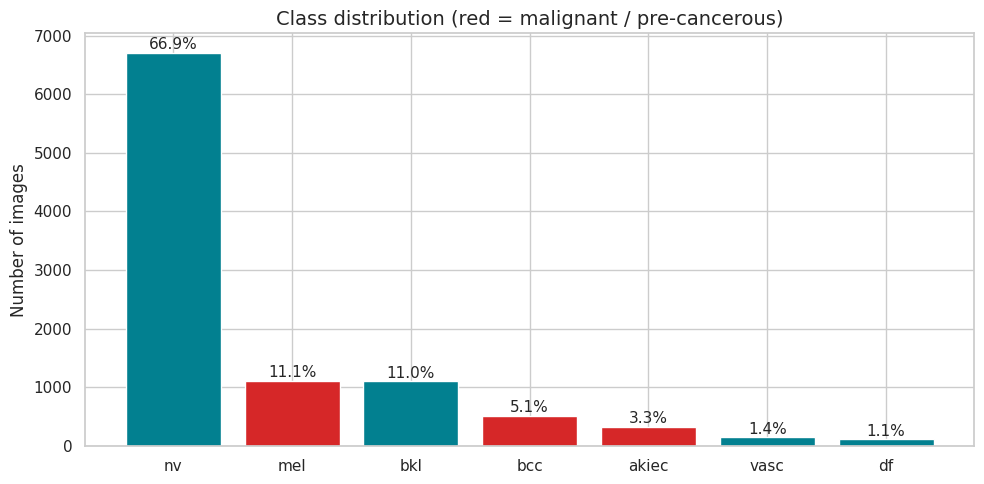

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [12]:
counts = meta["dx"].value_counts()
pct = counts / len(meta) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values,
              color=["#d62728" if c in MALIGNANT else "#028090" for c in counts.index])
for b, p in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 60,
            f"{p:.1f}%", ha="center", fontsize=11)
ax.set_title("Class distribution (red = malignant / pre-cancerous)", fontsize=14)
ax.set_ylabel("Number of images")
plt.tight_layout(); plt.show()

print(counts)

## 5. How were the labels verified? (`dx_type`)

This is what makes HAM10000 a *clinical-grade* dataset and not a scraped
image dump. Over half the diagnoses are confirmed by **histopathology**
(biopsy examined under a microscope — the gold standard), and essentially
all malignant cases are biopsy-confirmed. The rest: follow-up visits
(benign lesions that didn't change), expert consensus, or in-vivo confocal
microscopy.


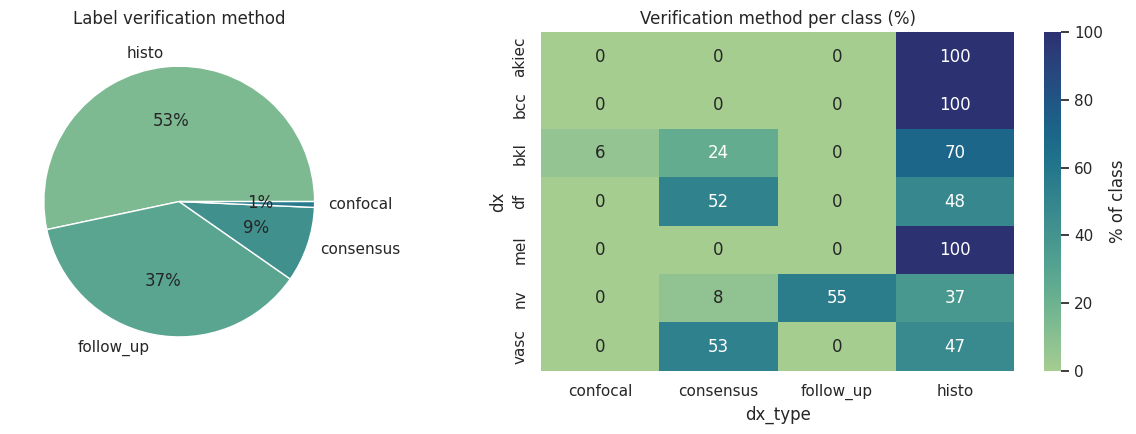

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

meta["dx_type"].value_counts().plot.pie(
    autopct="%1.0f%%", ax=axes[0], colors=sns.color_palette("crest"))
axes[0].set_title("Label verification method"); axes[0].set_ylabel("")

ct = pd.crosstab(meta["dx"], meta["dx_type"], normalize="index") * 100
sns.heatmap(ct, annot=True, fmt=".0f", cmap="crest", ax=axes[1],
            cbar_kws={"label": "% of class"})
axes[1].set_title("Verification method per class (%)")
plt.tight_layout(); plt.show()

## 6. Duplicate lesions — a data-leakage trap

One physical
lesion (`lesion_id`) can appear in several photos (`image_id`) — different
angles/magnifications. If we split train/validation randomly *by image*,
near-identical photos of the same lesion end up on both sides → the model
"recognizes" lesions it already saw → **inflated validation accuracy**.

**Decision:** we split by `lesion_id`, so a lesion is entirely in train OR
entirely in validation.

Images: 10015 | Unique lesions: 7470
→ 2545 images are 'extra' photos of an existing lesion

Photos per lesion:
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64


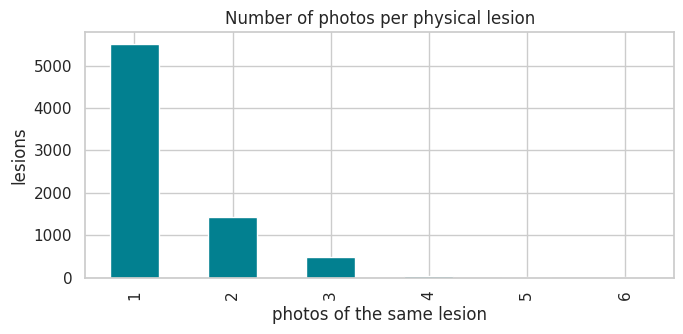

In [14]:
n_images = len(meta)
n_lesions = meta["lesion_id"].nunique()
imgs_per_lesion = meta.groupby("lesion_id").size()

print(f"Images: {n_images} | Unique lesions: {n_lesions}")
print(f"→ {n_images - n_lesions} images are 'extra' photos of an existing lesion")
print()
print("Photos per lesion:")
print(imgs_per_lesion.value_counts().sort_index())

imgs_per_lesion.value_counts().sort_index().plot.bar(
    color="#028090", figsize=(7, 3.5),
    title="Number of photos per physical lesion")
plt.xlabel("photos of the same lesion"); plt.ylabel("lesions")
plt.tight_layout(); plt.show()

## 7. Patient demographics — who is in this data?

Three things to look at:
- **Age**: distribution differs by class — melanoma and keratoses skew older,
  benign nevi are common in younger patients.
- **Sex**: roughly balanced.
- **Body location**: some classes concentrate on specific sites (e.g., actinic
  keratoses on face/scalp — sun exposure).
Patients come from Austria and Australia
→ predominantly light skin tones. The model may not generalize to darker
skin — a known fairness issue in dermatology AI.

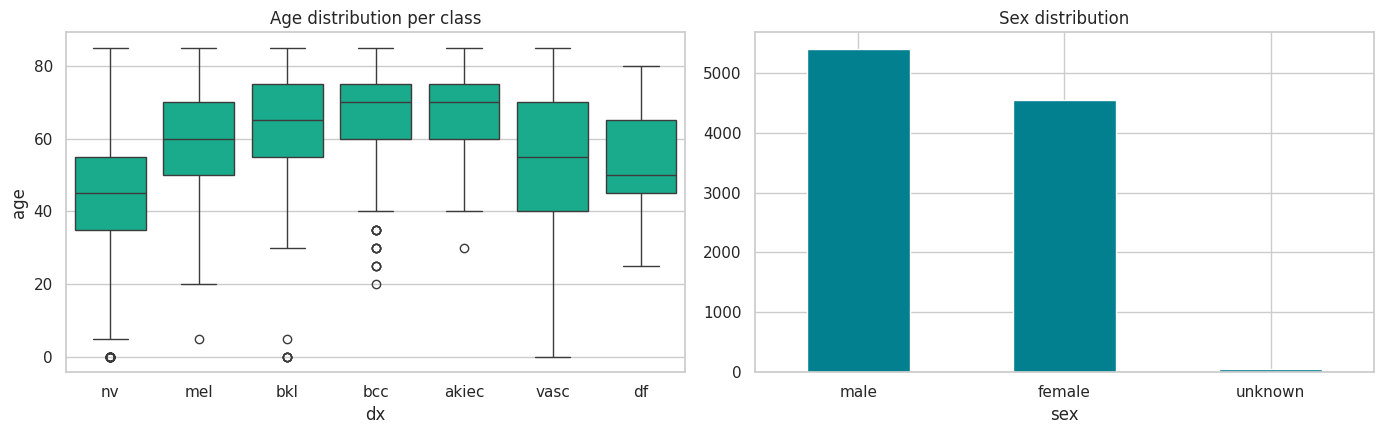

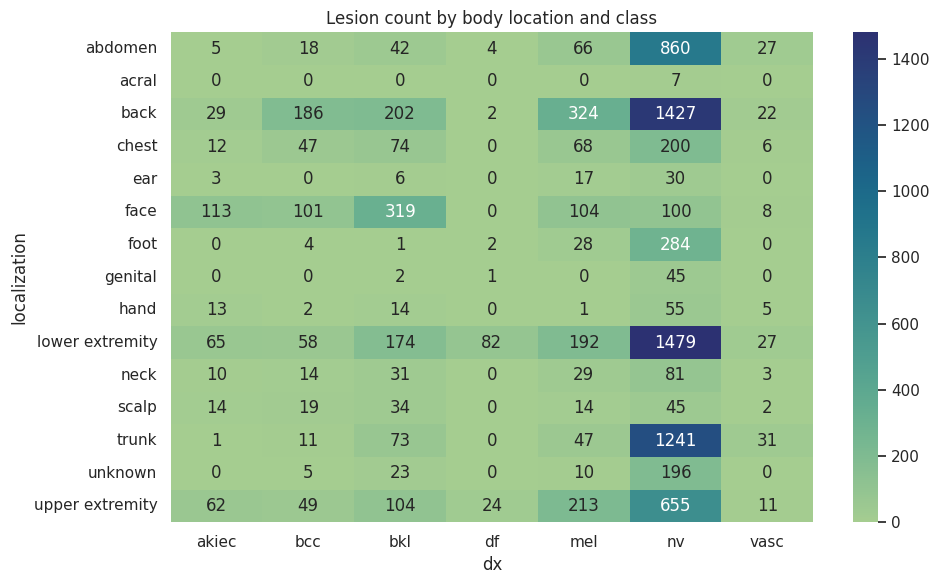

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=meta, x="dx", y="age", ax=axes[0], color="#02C39A",
            order=counts.index)
axes[0].set_title("Age distribution per class")

meta["sex"].value_counts().plot.bar(ax=axes[1], color="#028090")
axes[1].set_title("Sex distribution"); axes[1].tick_params(rotation=0)
plt.tight_layout(); plt.show()

# Body site vs class
loc = pd.crosstab(meta["localization"], meta["dx"])
plt.figure(figsize=(10, 6))
sns.heatmap(loc, cmap="crest", annot=True, fmt="d")
plt.title("Lesion count by body location and class")
plt.tight_layout(); plt.show()

## 8. Look at the images themselves



**What to notice on camera:**
- All images are 600×450 RGB dermatoscope photos → consistent quality, we
  resize to 224×224 (ResNet's expected input).
- **Melanoma (mel) and benign nevi (nv) look genuinely similar** — this is
  the hard part of the task, and it predicts where our confusion matrix will
  struggle. Dermatologists themselves find this distinction hard.
- Some images contain artifacts: hairs, ruler marks, air bubbles. Grad-CAM
  later lets us verify the model looks at the *lesion*, not the artifacts.

Size: (600, 450) | Mode: RGB
Distinct sizes in a 200-image sample: {(600, 450)}


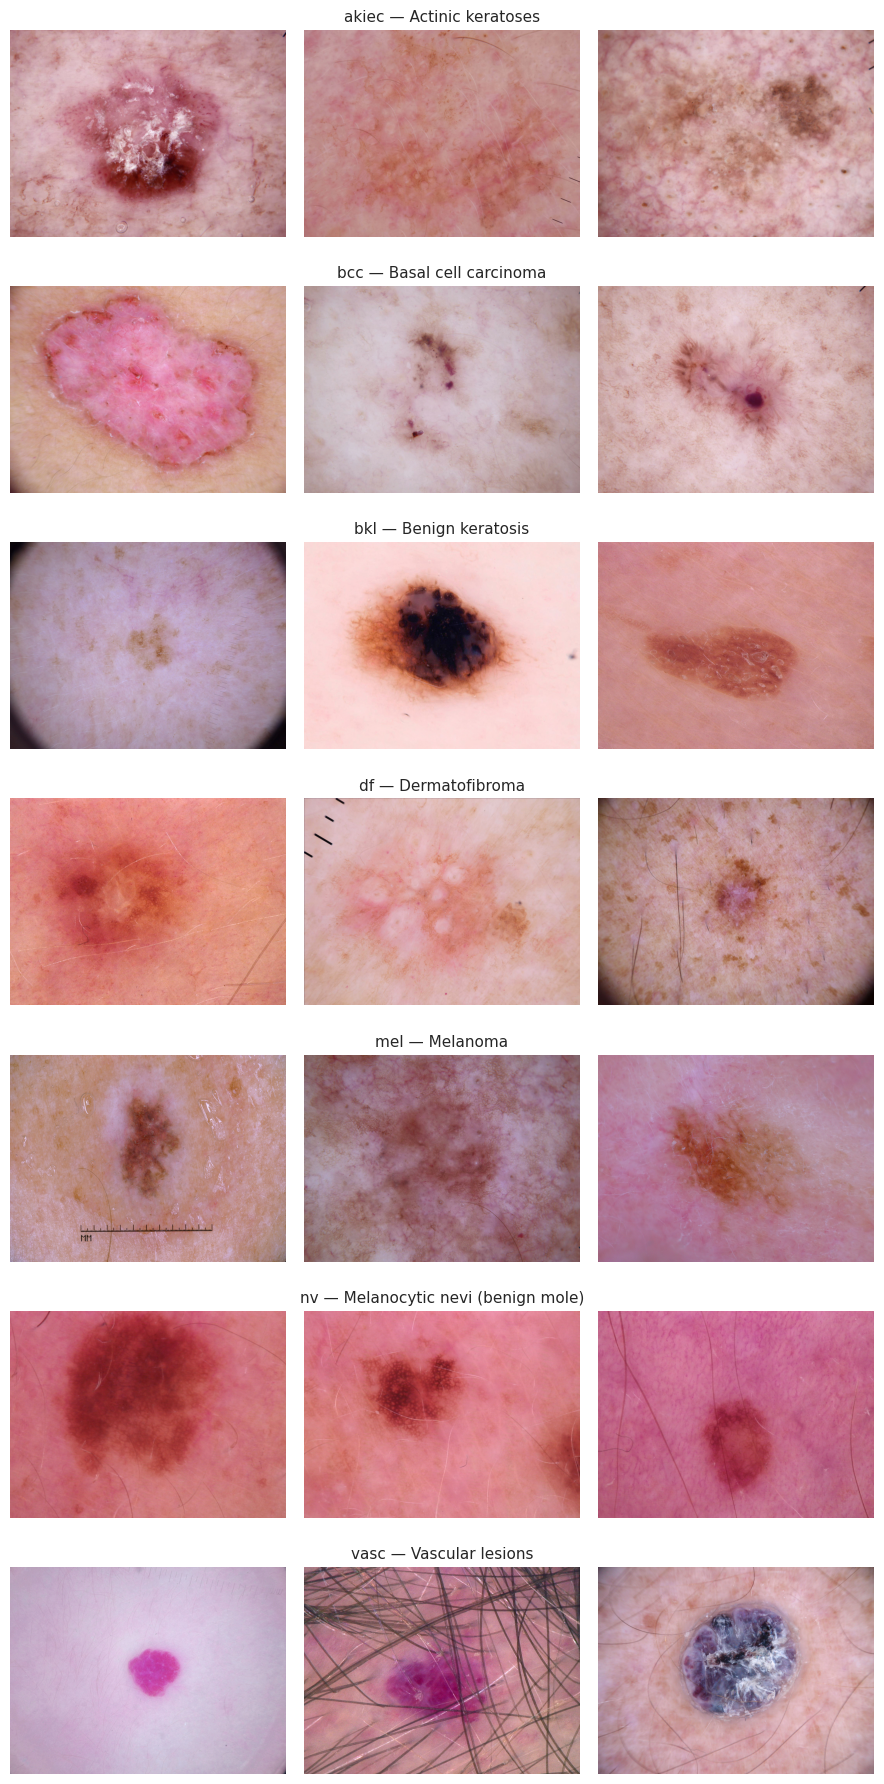

In [16]:
# Build path lookup
image_paths = {}
for part in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    folder = os.path.join(DATA_DIR, part)
    if os.path.isdir(folder):
        for f in os.listdir(folder):
            image_paths[os.path.splitext(f)[0]] = os.path.join(folder, f)
meta["path"] = meta["image_id"].map(image_paths)

# Technical check on a sample
sample = Image.open(meta["path"].iloc[0])
print("Size:", sample.size, "| Mode:", sample.mode)
sizes = {Image.open(p).size for p in meta["path"].sample(200, random_state=0)}
print("Distinct sizes in a 200-image sample:", sizes)

# 3 examples per class
classes = list(CLASS_NAMES)
fig, axes = plt.subplots(len(classes), 3, figsize=(9, 2.6 * len(classes)))
for i, c in enumerate(classes):
    paths = meta[meta["dx"] == c]["path"].sample(3, random_state=1).values
    for j, p in enumerate(paths):
        axes[i, j].imshow(Image.open(p))
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(c)
    axes[i, 1].set_title(f"{c} — {CLASS_NAMES[c]}", fontsize=11)
plt.tight_layout(); plt.show()

## 9. Pixel statistics (optional but impressive)

Mean color per class: melanocytic lesions tend to be darker/browner. This
confirms color is informative — and it's why we keep ColorJitter augmentation
*mild* (aggressive color shifts would destroy a diagnostic signal).

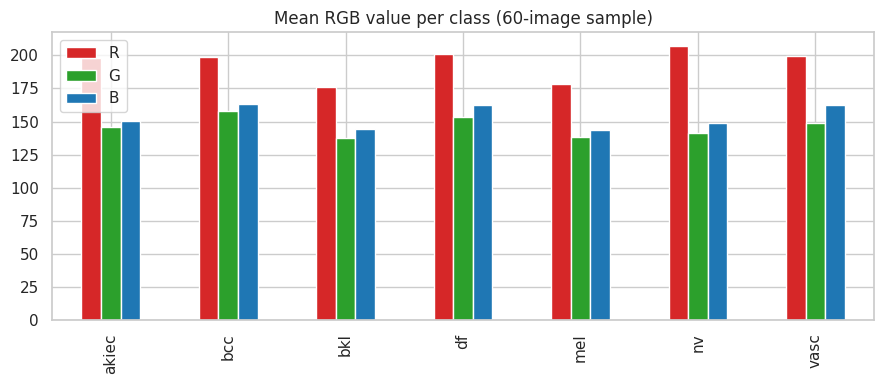

In [17]:
rows = []
for c in classes:
    paths = meta[meta["dx"] == c]["path"].sample(60, random_state=0)
    arr = np.stack([np.array(Image.open(p).resize((64, 64))) for p in paths])
    rows.append(arr.reshape(-1, 3).mean(axis=0))
rgb = pd.DataFrame(rows, index=classes, columns=["R", "G", "B"])
rgb.plot.bar(color=["#d62728", "#2ca02c", "#1f77b4"], figsize=(9, 4),
             title="Mean RGB value per class (60-image sample)")
plt.tight_layout(); plt.show()

## 10. EDA conclusions → our training approach

**What we found:**
1. 10,015 images, 7 classes, severe imbalance (67% `nv`, only 1.1% `df`)
2. Labels are clinical-grade (>50% biopsy-verified)
3. 46% of "extra" images are duplicate photos of existing lesions → leakage risk
4. Images are consistent 600×450 RGB dermatoscope photos
5. mel vs nv are visually similar → the clinically dangerous confusion
6. Demographic skew: light-skinned Austrian/Australian patients

**Therefore, our approach:**

| Step | Choice | Justified by |
|---|---|---|
| Split | 80/20 **by `lesion_id`**, stratified by class | finding 3 |
| Backbone | ImageNet-pretrained **ResNet-18** | 10k images is small for training from scratch (finding 1) |
| Head | Custom `Linear→ReLU→Dropout(0.4)→Linear` | our adaptation; dropout because dataset is small |
| Loss | **CrossEntropyLoss with class weights** `N/(K·n_c)` | finding 1 |
| Augmentation | H/V flips, rotation, *mild* ColorJitter | lesions have no orientation; color is diagnostic (§9) |
| Training | Phase 1: head only (3 ep, lr 1e-3) → Phase 2: unfreeze layer4 (5 ep, lr 1e-4, cosine) | protect pretrained weights from a random head's gradients |
| Metrics | Per-class **recall**, confusion matrix — with special attention to melanoma recall | findings 1 & 5 |
| Explainability | **Grad-CAM** in the demo | verify the model uses the lesion, not hairs/rulers (§8) |



In [18]:
from google.colab import files
import shutil, os

# Rebuild the path column (image_id -> file location in Colab)
image_paths = {}
for part in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    folder = os.path.join(DATA_DIR, part)
    if os.path.isdir(folder):
        for f in os.listdir(folder):
            image_paths[os.path.splitext(f)[0]] = os.path.join(folder, f)
meta["path"] = meta["image_id"].map(image_paths)

# Download one example per class
for dx in meta["dx"].unique():
    src = meta[meta["dx"] == dx]["path"].iloc[0]
    dst = f"example_{dx}.jpg"
    shutil.copy(src, dst)
    files.download(dst)

print("Done — 7 files should be downloading.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done — 7 files should be downloading.
